In [ ]:
!pip install transformers datasets scikit-learn

In [2]:
from google.colab import files
uploaded = files.upload()

Saving training.1600000.processed.noemoticon.csv to training.1600000.processed.noemoticon.csv


In [3]:
import pandas as pd

df = pd.read_csv("training.1600000.processed.noemoticon.csv", encoding="latin-1", header=None)
df.head()

,0,1,2,3,4,5
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [4]:
df = df[[0,5]]
df.columns = ["label","text"]

In [5]:
df["label"] = df["label"].replace(4,1)

In [6]:
df = df.sample(5000)

In [7]:
from sklearn.model_selection import train_test_split

train_texts, test_texts, train_labels, test_labels = train_test_split(
    df["text"], df["label"], test_size=0.2
)

In [8]:
from transformers import DistilBertTokenizerFast

tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [9]:
train_encodings = tokenizer(list(train_texts), truncation=True, padding=True)
test_encodings = tokenizer(list(test_texts), truncation=True, padding=True)

In [10]:
import torch

class TwitterDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels.iloc[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = TwitterDataset(train_encodings, train_labels)
test_dataset = TwitterDataset(test_encodings, test_labels)

In [11]:
from transformers import DistilBertForSequenceClassification

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [22]:
import transformers
print(f"Transformers version: {transformers.__version__}")

Transformers version: 5.0.0


In [24]:
from transformers import Trainer, TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",      # Correct parameter name for v5.0.0
    save_strategy="epoch",       # This one is correct
    logging_dir="./logs",
    logging_steps=10,
    report_to="none",            # Optional: disable wandb/tensorboard
    load_best_model_at_end=True, # Optional: load best model at end of training
    metric_for_best_model="eval_loss", # Optional: metric to use for best model
    greater_is_better=False,     # Optional: False because we want lower loss
)
print("TrainingArguments created successfully!")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


TrainingArguments created successfully!


In [26]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
)
print("Trainer created successfully!")

Trainer created successfully!


In [27]:
print("Evaluating before training...")
initial_eval_results = trainer.evaluate()
print(f"Initial evaluation results: {initial_eval_results}")

Evaluating before training...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Initial evaluation results: {'eval_loss': 0.6990131735801697, 'eval_model_preparation_time': 0.0069, 'eval_runtime': 123.6409, 'eval_samples_per_second': 8.088, 'eval_steps_per_second': 0.51}


In [29]:
print("Starting training.")
trainer.train()
print("Training completed!")

Starting training.


Epoch,Training Loss,Validation Loss,Model Preparation Time
1,0.483150,0.422767,0.006900
2,0.218077,0.477994,0.006900
3,0.085538,0.681735,0.006900


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Training completed!


In [30]:
model_save_path = "./intent_classification_model"
tokenizer_save_path = "./intent_classification_model"

model.save_pretrained(model_save_path)
tokenizer.save_pretrained(tokenizer_save_path)
print(f"Model saved to {model_save_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to ./intent_classification_model



Starting model evaluation...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



Basic evaluation results:
  eval_loss: 0.4227
  eval_model_preparation_time: 0.0069
  eval_runtime: 106.4993
  eval_samples_per_second: 9.3900
  eval_steps_per_second: 0.5920
  epoch: 3.0000

----------------------------------------
Detailed results analysis:
----------------------------------------

Overall Accuracy: 0.8080
Precision: 0.7801
Recall: 0.8469
F1 Score: 0.8121

Complete Classification Report:
              precision    recall  f1-score   support

Negative (0)       0.84      0.77      0.80       510
Positive (1)       0.78      0.85      0.81       490

    accuracy                           0.81      1000
   macro avg       0.81      0.81      0.81      1000
weighted avg       0.81      0.81      0.81      1000



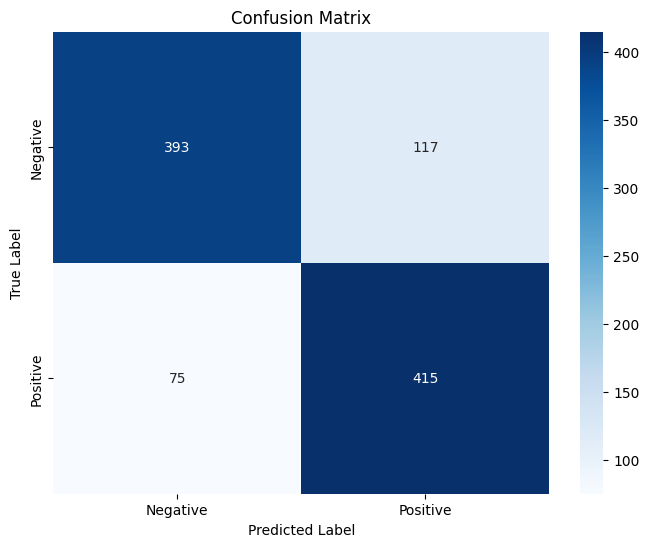


Testing on examples from test data:

Text: @DirtyGirl29 No videos on youtube, i searched ...
True: Negative | Predicted: Negative (Correct)

Text: Grand major insomnia, ...
True: Negative | Predicted: Negative (Correct)

Text: @evernote @eyeficard I need one of these! Was just thinking about it earlier today as I downloaded p...
True: Negative | Predicted: Positive (Incorrect)

Text: @hblake13 I'm sorry... I didn't even watch the 2nd half.  Kind of knew at halftime it was pretty muc...
True: Negative | Predicted: Negative (Correct)

Text: @David_Henrie goodnight then ...
True: Positive | Predicted: Positive (Correct)


In [32]:
# Add this code after the Training completed! line
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

print("\n" + "="*60)
print("Starting model evaluation...")
print("="*60)

# Evaluate the model
eval_results = trainer.evaluate()
print("\nBasic evaluation results:")
for key, value in eval_results.items():
    print(f"  {key}: {value:.4f}")

# Get predictions for detailed analysis
print("\n" + "-"*40)
print("Detailed results analysis:")
print("-"*40)

predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary')

print(f"\nOverall Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Full classification report
print("\n" + "="*60)
print("Complete Classification Report:")
print("="*60)
print(classification_report(y_true, y_pred, target_names=['Negative (0)', 'Positive (1)']))

# Plot confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Test on random examples from test data
print("\n" + "="*60)
print("Testing on examples from test data:")
print("="*60)

# Select 5 random examples
import random
indices = random.sample(range(len(test_texts)), 5)

for idx in indices:
    text = test_texts.iloc[idx]
    true_label = test_labels.iloc[idx]
    pred_label = y_pred[idx]

    sentiment_true = "Positive" if true_label == 1 else "Negative"
    sentiment_pred = "Positive" if pred_label == 1 else "Negative"
    correct = "Correct" if true_label == pred_label else "Incorrect"

    print(f"\nText: {text[:100]}...")
    print(f"True: {sentiment_true} | Predicted: {sentiment_pred} ({correct})")